In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

### Part 1

In [9]:
# Parameters
S0, K, T, r, sig = 100, 99, 1, 0.06, 0.20
mu = 0.08

In [10]:
# Black-Scholes call price and delta functions
def bs_call(S, K, tau, r, sig):
    if tau < 1e-12:
        return max(S - K, 0)
    # Calculating d1 and d2 for the Black-Scholes formula
    d1=(np.log(S/K)+(r+0.5*sig**2)*tau)/(sig*np.sqrt(tau))
    d2=d1-sig*np.sqrt(tau)
    return S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2)

def bs_delta(S, K, tau, r, sig):
    if tau < 1e-12:
        return 1 if S > K else 0
    # Calculating d1 for the delta formula
    d1=(np.log(S/K)+(r+0.5*sig**2)*tau)/(sig*np.sqrt(tau))
    return norm.cdf(d1)

In [11]:
# Function to run the simulation for given parameters
def run(sig_s, sig_h, n_s, n_p=10000):
    dt=T/n_s
    pnl=np.zeros(n_p)
    # Simulate n_p paths
    for p in range(n_p):
        S = S0
        cash=bs_call(S0, K, T, r, sig_h)
        delta=bs_delta(S0, K, T, r, sig_h)
        cash-=delta*S0
        # Simulate the path with rebalancing
        for i in range(1, n_s + 1):
            
            Z = np.random.randn()
            # euler discretization of the underlying price
            S_n = S + mu*S*dt + sig_s*S*np.sqrt(dt)*Z

            cash*=np.exp(r*dt)
            tau=T - i*dt
            # Rebalance if not at maturity, otherwise close the position
            if i < n_s:
                delta_n = bs_delta(S_n, K, tau, r, sig_h)
                cash-=(delta_n - delta)*S_n
                delta=delta_n
            else:
                cash += delta * S_n
                cash -= max(S_n - K, 0.0)

            S = S_n
        pnl[p] = cash
    return pnl

In [12]:
# Running the simulations for different frequencies
freqs = {"Daily (252)": 252, "2-Day (126)": 126, "Weekly (52)": 52,"Biweekly (26)": 26, "Monthly (12)": 12}

# Run the simulations and collect results
res = {}
for lbl, n in freqs.items():
    pnl = run(sig, sig, n)
    res[lbl] = pnl
    print(f"{lbl:20s}  mean={np.mean(pnl):+.4f}  std={np.std(pnl):.4f}")

Daily (252)           mean=-0.0031  std=0.4182
2-Day (126)           mean=+0.0081  std=0.5992
Weekly (52)           mean=+0.0032  std=0.9072
Biweekly (26)         mean=+0.0095  std=1.2797
Monthly (12)          mean=+0.0136  std=1.8401


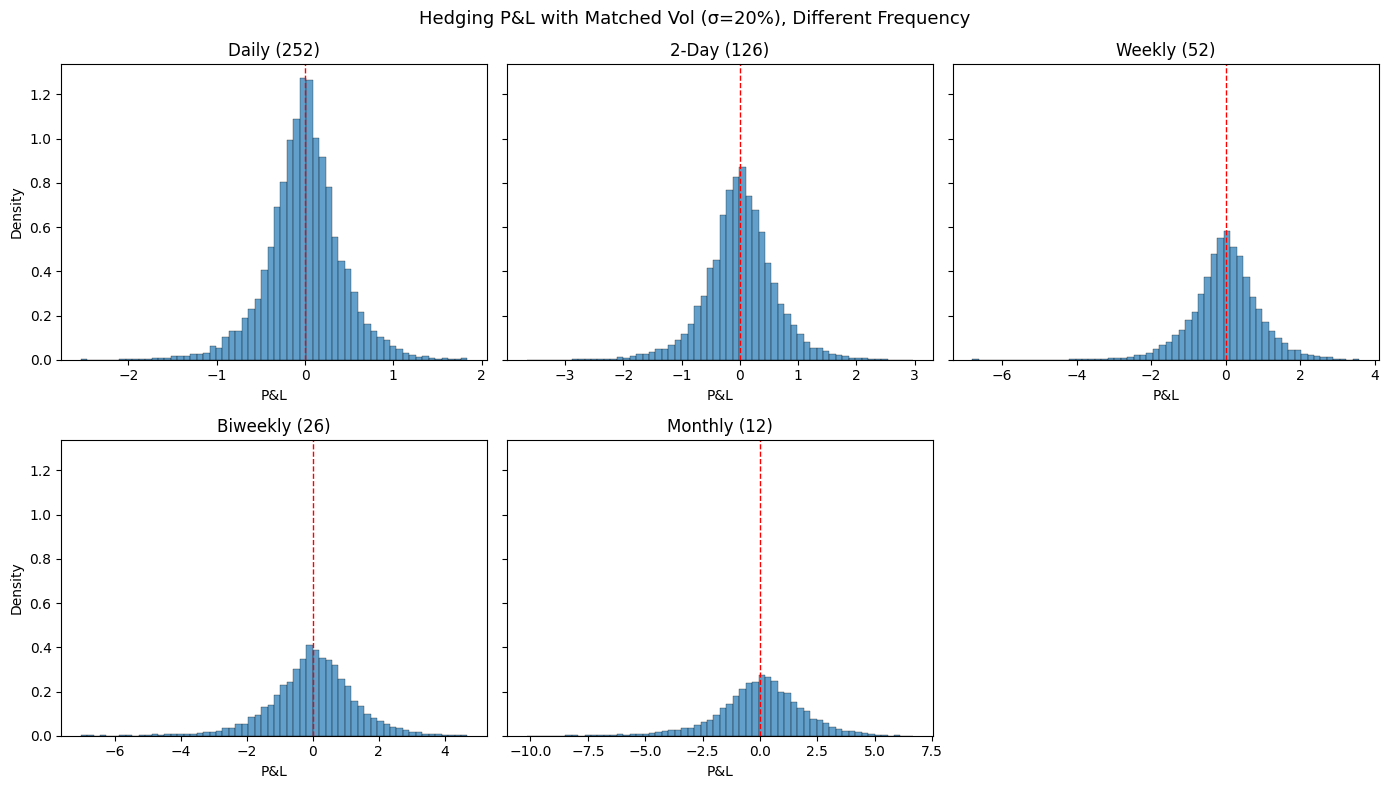

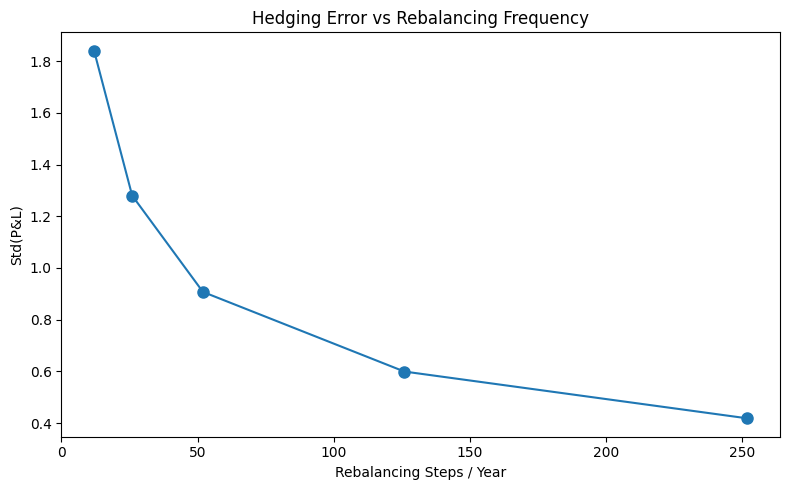

In [13]:
# P&L histograms
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes_flat = axes.flatten()

for ax, (label, pnl) in zip(axes_flat, res.items()):
    ax.hist(pnl, bins=60, density=True, alpha=0.7, edgecolor="k", lw=0.3)
    ax.axvline(0, color="red", ls="--", lw=1)
    ax.set_title(label)
    ax.set_xlabel("P&L")

axes[0, 0].set_ylabel("Density")
axes[1, 0].set_ylabel("Density")
axes_flat[-1].set_visible(False)

fig.suptitle("Hedging P&L with Matched Vol (σ=20%), Different Frequency", fontsize=13)
plt.tight_layout()
plt.savefig("task1_histograms.png", dpi=150)
plt.show()

# Std vs frequency
ns = list(freqs.values())
sds = [np.std(res[l]) for l in freqs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ns, sds, "o-", ms=8)
ax.set_xlabel("Rebalancing Steps / Year")
ax.set_ylabel("Std(P&L)")
ax.set_title("Hedging Error vs Rebalancing Frequency")
plt.tight_layout()
# plt.savefig("task1_std_vs_freq.png", dpi=150)
plt.show()


### Discussion

Both the simulation and the hedging use the same volatility of 20%, so the only source of error is how often we rebalance.

From the histograms we can see that the P&L is centered around zero for all frequencies, this makes sense because when we hedge with the correct vol there's no systematic bias. The spread of the distribution gets wider as we go from daily to monthly rebalancing, which shows up clearly in the second plot.

From the std vs frequency plot we can see that daily hedging gives a std of about 0.42 while monthly rebalancing gives up to around 1.84. The curve follows a roughly √Δt decay. This happens because delta hedging is only perfect in continuous time. Between rebalances, our delta is stale and the gamma exposure doesn't cancel out exactly. Smaller steps mean smaller mismatches at each rebalance, so the errors stay small and average out better over the year.

In [14]:
# Simulating a single path with daily rebalancing to visualize the dynamics
np.random.seed(10005)
n_s=252
dt = T/n_s

S_path, del_path, pnl_path = [S0], [bs_delta(S0, K, T, r, sig)], [0]
S, cash = S0, bs_call(S0, K, T, r, sig) - bs_delta(S0, K, T, r, sig) * S0
delta = del_path[0]
# Simulate the path
for i in range(1, n_s+1):
    S = S + mu*S*dt + sig*S*np.sqrt(dt)*np.random.randn()
    cash*=np.exp(r*dt)
    tau=T - i*dt
    # Rebalance if not at maturity
    if i < n_s:
        del_new=bs_delta(S, K, tau, r, sig)
        cash-=(del_new - delta)*S
        delta=del_new
        S_path.append(S)
        del_path.append(delta)
        pnl_path.append(cash + delta*S - bs_call(S, K, tau, r, sig))
        # At maturity, close the position
    else:
        cash+=delta*S
        cash-=max(S - K, 0.0)
        S_path.append(S)
        del_path.append(0)
        pnl_path.append(cash)

t = np.linspace(0, T, n_s + 1)

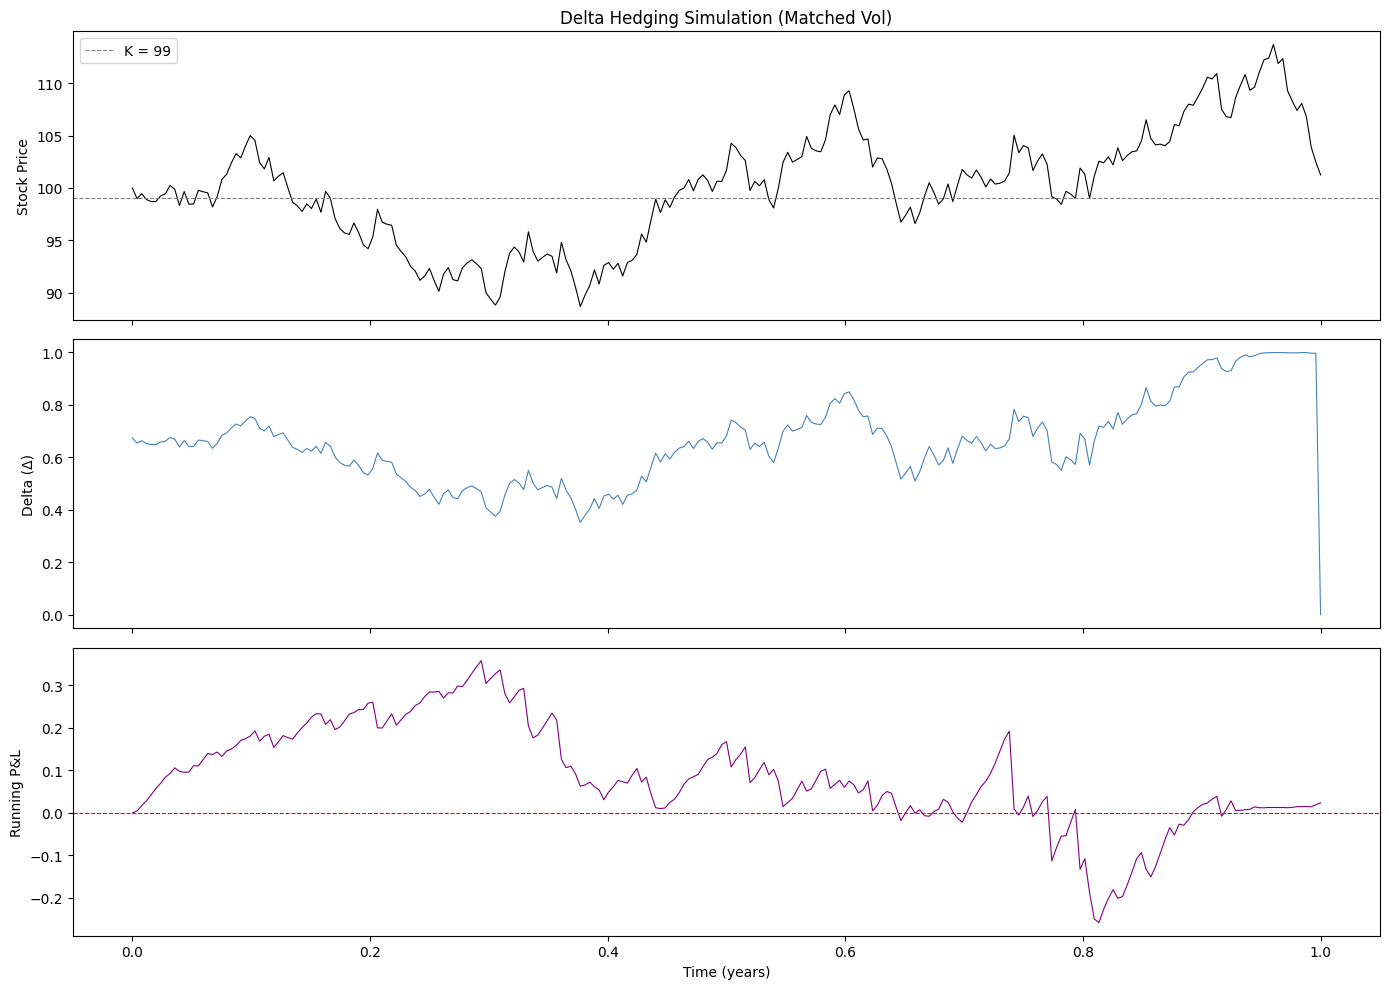

In [15]:
# Plotting the single path results
fig, ax = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

ax[0].plot(t, S_path, color="black", lw=0.8)
ax[0].axhline(K, color="gray", ls="--", lw=0.8, label=f"K = {K}")
ax[0].set_ylabel("Stock Price")
ax[0].set_title("Delta Hedging Simulation (Matched Vol)")
ax[0].legend()

ax[1].plot(t, del_path, color="steelblue", lw=0.8)
ax[1].set_ylabel("Delta (Δ)")

ax[2].plot(t, pnl_path, color="purple", lw=0.8)
ax[2].axhline(0, color="red", ls="--", lw=0.8)
ax[2].set_ylabel("Running P&L")
ax[2].set_xlabel("Time (years)")

plt.tight_layout()
# plt.savefig("task1_single_path.png", dpi=150)
plt.show()

### Discussion 
This plot shows a single path of the delta hedging simulation with matched volatility (20%). The stock is around the strike K=99 for most of the year before rallying towards the end. Because the stock stays near the strike, delta fluctuates a lot in the 0.4 to 0.8 range, meaning we're constantly rebalancing our hedge. The running P&L stays close to zero throughout, which is what we expect when the hedging vol matches the simulation vol. The small fluctuations we see are just discretization noise from daily rebalancing. At maturity we sell all shares and settle the option payoff (delta drops to 0), and the final P&L is close to zero.

### Part 2


In [16]:
# Varying simulation volatility and fixed hedging volatility
sims_a = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
res_a = {}
for s in sims_a:
    pnl = run(s, sig, 252)
    res_a[s] = pnl
    print(f"  σ_sim={s:.0%}  mean={np.mean(pnl):+.4f}  std={np.std(pnl):.4f}")


  σ_sim=10%  mean=+3.4701  std=1.1427
  σ_sim=15%  mean=+1.8364  std=0.7466
  σ_sim=20%  mean=+0.0019  std=0.4144
  σ_sim=25%  mean=-1.9297  std=1.0159
  σ_sim=30%  mean=-3.9055  std=1.9401
  σ_sim=35%  mean=-5.8371  std=2.9721
  σ_sim=40%  mean=-7.8395  std=4.1027


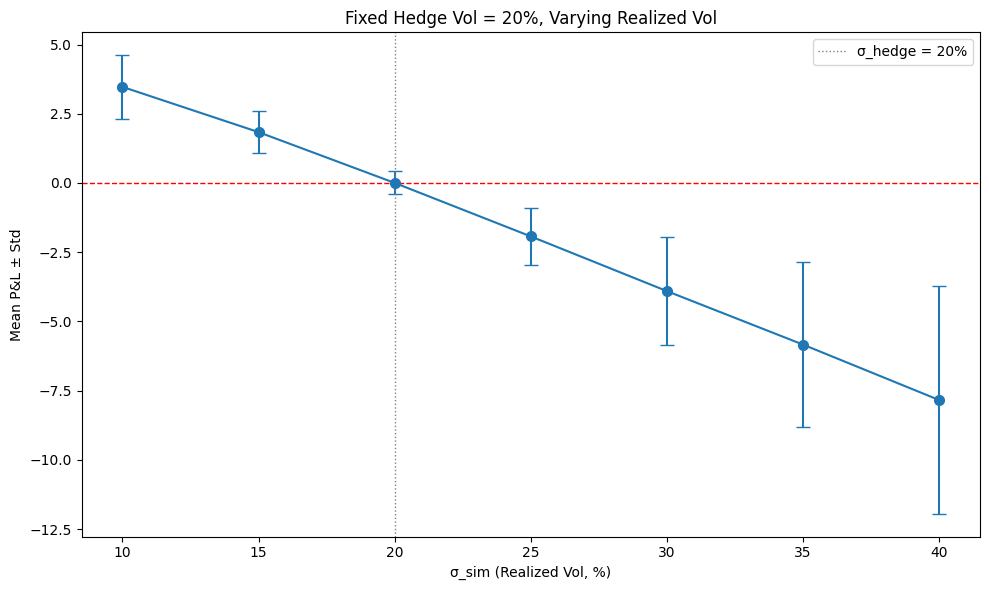

In [17]:
# Plotting the results for varying simulation volatility and fixed hedge volatility
avgs_a = [np.mean(res_a[s]) for s in sims_a]
stds_a = [np.std(res_a[s]) for s in sims_a]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar([s*100 for s in sims_a], avgs_a, yerr=stds_a,
            fmt="o-", capsize=5, ms=7)
ax.axhline(0, color="red", ls="--", lw=1)
ax.axvline(20, color="gray", ls=":", lw=1, label="σ_hedge = 20%")
ax.set_xlabel("σ_sim (Realized Vol, %)")
ax.set_ylabel("Mean P&L ± Std")
ax.set_title("Fixed Hedge Vol = 20%, Varying Realized Vol")
ax.legend()
plt.tight_layout()
# plt.savefig("task2a.png", dpi=150)
plt.show()

### Discussion

In this plot, we fix the hedging vol at 20% and vary the realized vol. When the realized vol is higher than what we hedge with, the stock moves more than our model expects and the rehedging costs eat into our P&L. When realized vol is lower, we collected too much premium relative to the actual risk, so we profit. The mean P&L crosses zero exactly at σ_sim = 20% where the two match.

In [18]:
# Varying hedge volatility and fixing simulation volatility

hedges_b = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]
res_b = {}
for s in hedges_b:
    pnl = run(sig, s, 252)
    res_b[s] = pnl
    print(f"  σ_hedge={s:.0%}  mean={np.mean(pnl):+.4f}  std={np.std(pnl):.4f}")


  σ_hedge=10%  mean=-3.5136  std=2.1256
  σ_hedge=15%  mean=-1.8240  std=0.9859
  σ_hedge=20%  mean=+0.0009  std=0.4202
  σ_hedge=25%  mean=+1.9039  std=0.7943
  σ_hedge=30%  mean=+3.8472  std=1.2911
  σ_hedge=35%  mean=+5.7873  std=1.6848
  σ_hedge=40%  mean=+7.7851  std=2.0358


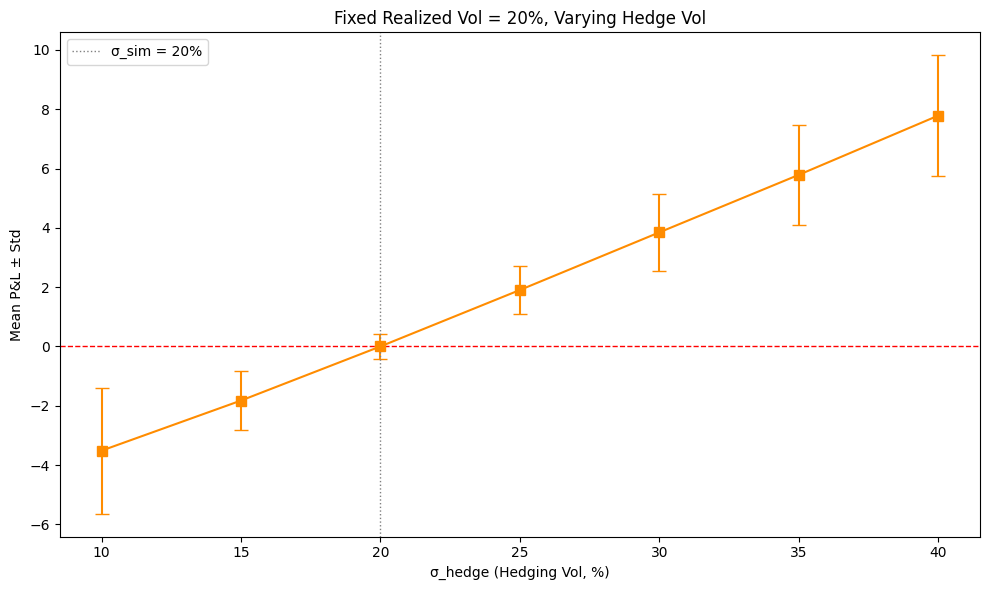

In [19]:
# plotting the results for varying hedge volatility and fixed simulation volatility

avgs_b = [np.mean(res_b[s]) for s in hedges_b]
stds_b = [np.std(res_b[s]) for s in hedges_b]

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar([s*100 for s in hedges_b], avgs_b, yerr=stds_b,
            fmt="s-", capsize=5, ms=7, color="darkorange")
ax.axhline(0, color="red", ls="--", lw=1)
ax.axvline(20, color="gray", ls=":", lw=1, label="σ_sim = 20%")
ax.set_xlabel("σ_hedge (Hedging Vol, %)")
ax.set_ylabel("Mean P&L ± Std")
ax.set_title("Fixed Realized Vol = 20%, Varying Hedge Vol")
ax.legend()
plt.tight_layout()
# plt.savefig("task2b.png", dpi=150)
plt.show()


### Discussion

In this plot, we fix the realized vol at 20% and vary the hedging vol. A higher hedging vol means we price the option more expensively while reality is calmer, so we make money. A lower hedging vol means we undercharged for the option and lose money on average.

Both plots confirm the same thing that the P&L is driven by the difference between σ²_hedge and σ²_sim, weighted by the dollar gamma ½ΓS² at each step. When they match, mean P&L is zero. The error bars also grow as the mismatch increases, showing that not only does the bias get worse but the variance of outcomes increases too.

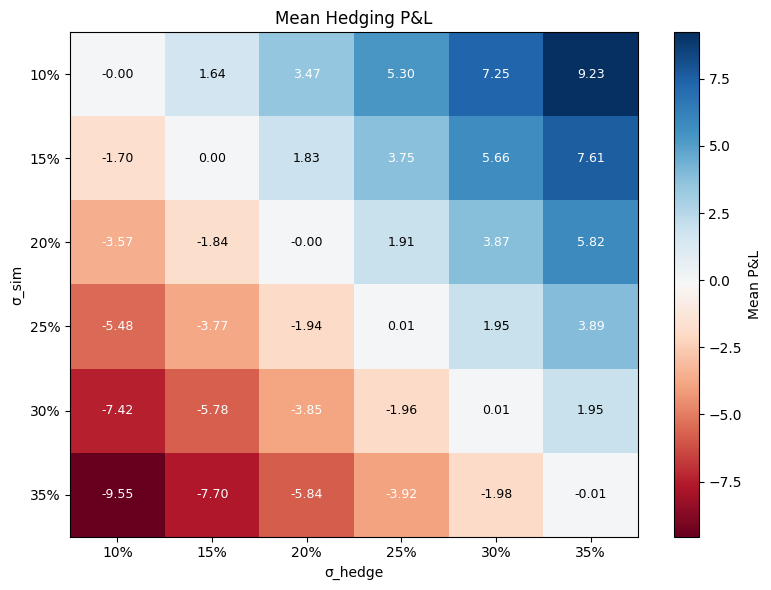

In [20]:
# plotting heatmap of mean P&L for different σ_sim and σ_hedge
grid = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
avg_pnl = np.zeros((len(grid), len(grid)))

for i, s_sim in enumerate(grid):
    for j, s_h in enumerate(grid):
        pnl = run(s_sim, s_h, 252, 5000)
        avg_pnl[i, j] = np.mean(pnl)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(avg_pnl, cmap="RdBu", aspect="auto")
ax.set_xticks(range(len(grid)))
ax.set_xticklabels([f"{s:.0%}" for s in grid])
ax.set_yticks(range(len(grid)))
ax.set_yticklabels([f"{s:.0%}" for s in grid])
ax.set_xlabel("σ_hedge")
ax.set_ylabel("σ_sim")
ax.set_title("Mean Hedging P&L")
for i in range(len(grid)):
    for j in range(len(grid)):
        ax.text(j, i, f"{avg_pnl[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(avg_pnl[i,j]) > 2 else "black", fontsize=9)
plt.colorbar(im, label="Mean P&L")
plt.tight_layout()
# plt.savefig("task2_heatmap.png", dpi=150)
plt.show()

The heatmap shows the mean hedging P&L across all combinations of realized vol (σ_sim) and hedging vol (σ_hedge). The diagonal where σ_sim = σ_hedge is zero, confirming break even when the model is correct. Above the diagonal (σ_hedge > σ_sim) is blue/positive, meaning we overcharged for the option (make money). Below the diagonal (σ_sim > σ_hedge) is red/negative, meaning we underpriced it (lose money). The further away from the diagonal, the larger the P&L magnitude.

### Part 3

We want to show that for the expected hedging P&L to vanish, the implied volatility must match the realized volatility on average, weighted by discounted dollar gamma.

**Setup** 

We are short one call option $C(t, S; \sigma_{\text{imp}})$ priced under the BS PDE (4) with implied vol $\sigma_{\text{imp}}$ and we delta hedge by holding $\Delta_t = \frac{\partial C}{\partial S}$ shares. The remaining cash earns the risk free rate $r$. The actual stock dynamics under $\mathbb{P}$ follow the equation (5),

$$\frac{dS_t}{S_t} = r\,dt + \sigma_t\,dW_t^{\mathbb{P}}$$

where $\sigma_t$ is the instantaneous realized volatility, which may differ from $\sigma_{\text{imp}}$.

**Hedging portfolio P&L** 

The instantaneous change in the hedged portfolio value is,

$$d\Pi = \Delta_t\,dS_t - dC_t + r(C_t - \Delta_t S_t)\,dt$$

The first term is the gain from holding shares, the second is the loss from being short the option and the third is interest earned on the net cash position $C_t - \Delta_t S_t$.

**Applying Itô's lemma** 

Since $C$ is a function of $t$ and $S$, we expand $dC_t$ using Itô's lemma with the actual stock dynamics,

$$dC_t = \frac{\partial C}{\partial t}\,dt + \frac{\partial C}{\partial S}\,dS_t + \frac{1}{2}\frac{\partial^2 C}{\partial S^2}\,\sigma_t^2 S_t^2\,dt$$

Substituting into $d\Pi$ and writing $\Gamma_t = \frac{\partial^2 C}{\partial S^2}$,

$$d\Pi = \Delta_t\,dS_t - \left[\frac{\partial C}{\partial t}\,dt + \Delta_t\,dS_t + \frac{1}{2}\Gamma_t\,\sigma_t^2 S_t^2\,dt\right] + r(C_t - \Delta_t S_t)\,dt$$

The $\Delta_t\,dS_t$ terms cancel and we are left with,

$$d\Pi = \left[rC_t - rS_t\Delta_t - \frac{\partial C}{\partial t} - \frac{1}{2}\Gamma_t\,\sigma_t^2 S_t^2\right]dt$$

**Using the BS PDE** 

Since $C$ satisfies the Black-Scholes PDE (4) with $\sigma_{\text{imp}}$, we have

$$rC_t - rS_t\frac{\partial C}{\partial S} - \frac{\partial C}{\partial t} = \frac{1}{2}\sigma_{\text{imp}}^2\,S_t^2\,\Gamma_t$$

Substituting this into the P&L expression, we have

$$d\Pi = \frac{1}{2}\Gamma_t\,S_t^2\left(\sigma_{\text{imp}}^2 - \sigma_t^2\right)dt$$

The instantaneous hedging P&L is entirely determined by the dollar gamma $\frac{1}{2}\Gamma_t S_t^2$ multiplied by the difference between implied and realized variance.

**Integrating and discounting** 

The total P&L discounted to $t = 0$ is obtained by integrating over the life of the option,

$$\Pi = \int_0^T e^{-rt}\,\frac{1}{2}\,S_t^2\,\frac{\partial^2 C_{\sigma_{\text{imp}}}}{\partial S_t^2}\left(\sigma_{\text{imp}}^2 - \sigma_t^2\right)dt$$

Setting $\mathbb{E}[\Pi] = 0$ for the expected P&L to vanish gives us equation (6),

$$\mathbb{E}\left[\int_0^T e^{-rt}\,\frac{1}{2}\,S_t^2\,\frac{\partial^2 C_{\sigma_{\text{imp}}}}{\partial S_t^2}\left(\sigma_{\text{imp}}^2 - \sigma_t^2\right)dt\right] = 0$$

**Interpretation** 

For the hedge to break even on average, $\sigma_{\text{imp}}$ must equal $\sigma_t$ in a weighted average sense, where the weights are the discounted dollar gamma $e^{-rt}\frac{1}{2}S_t^2\Gamma_t$. Since gamma is largest when the option is near the money and close to expiry, the vol mismatch in those regions has the biggest impact on hedging P&L. This is consistent with what we observed in Part 2, when $\sigma_{\text{sim}} \neq \sigma_{\text{hedge}}$, the mean P&L is nonzero and proportional to $(\sigma_{\text{hedge}}^2 - \sigma_{\text{sim}}^2)$ weighted by dollar gamma.